<a href="https://colab.research.google.com/github/claranvt/Data-Analyst/blob/Python/KELOMPOK%205_TUBES%20AI_NETWORK%20SLICING_DECISION%20TREE%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TUGAS AI & BIG DATA - Network Slicing**
**DATASET**   >> KLASIFIKASI *NETWORK SLICING*

**ALGORITMA** >> DECISION TREE

**ANGGOTA KELOMPOK 5 :**


1.   Zahra Talitha Putri (101012300192)
2.   Siti Rabiah Tuladawiah (101012300304)

1.   Aizza Kamelia Insani (101012300341)
2.   Clara Novita Fitriani (101012330008)
1.   Rahma Aliyyah (10101230090809)


**Import** **Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Load Dataset**

In [ ]:
data = "https://raw.githubusercontent.com/zahratalitha/dataset-project/refs/heads/main/Network%20Slicing.csv"
df = pd.read_csv(data)


**Display Initial Data**

In [ ]:
df.head()

,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


**Data** **Info**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31583 entries, 0 to 31582
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LTE/5g Category       31583 non-null  int64  
 1   Time                  31583 non-null  int64  
 2   Packet Loss Rate      31583 non-null  float64
 3   Packet delay          31583 non-null  int64  
 4   IoT                   31583 non-null  int64  
 5   LTE/5G                31583 non-null  int64  
 6   GBR                   31583 non-null  int64  
 7   Non-GBR               31583 non-null  int64  
 8   AR/VR/Gaming          31583 non-null  int64  
 9   Healthcare            31583 non-null  int64  
 10  Industry 4.0          31583 non-null  int64  
 11  IoT Devices           31583 non-null  int64  
 12  Public Safety         31583 non-null  int64  
 13  Smart City & Home     31583 non-null  int64  
 14  Smart Transportation  31583 non-null  int64  
 15  Smartphone         

**Descriptive Statistics**

In [ ]:
df.describe()

,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
count,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000
mean,10.974923,11.476459,0.003079,114.126745,0.468100,0.531900,0.441187,0.558813,0.106291,0.057943,0.116107,0.057879,0.059716,0.117722,0.058734,0.425609,1.702150
std,6.053641,6.915643,0.004344,106.320976,0.498989,0.498989,0.496537,0.496537,0.308215,0.233639,0.320358,0.233519,0.236963,0.322283,0.235130,0.494443,0.822956
min,1.000000,0.000000,0.000001,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,6.000000,0.000001,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,11.000000,11.000000,0.001000,75.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,17.000000,0.010000,150.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,22.000000,23.000000,0.010000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


**Check Empty Value**

In [ ]:
df.isnull().sum()

,0
LTE/5g Category,0
Time,0
Packet Loss Rate,0
Packet delay,0
IoT,0
LTE/5G,0
GBR,0
Non-GBR,0
AR/VR/Gaming,0
Healthcare,0


**Looking For Unique Value**

In [ ]:
df.nunique()

,0
LTE/5g Category,22
Time,24
Packet Loss Rate,3
Packet delay,7
IoT,2
LTE/5G,2
GBR,2
Non-GBR,2
AR/VR/Gaming,2
Healthcare,2


**Data** **Distribution**

<Figure size 1200x600 with 0 Axes>

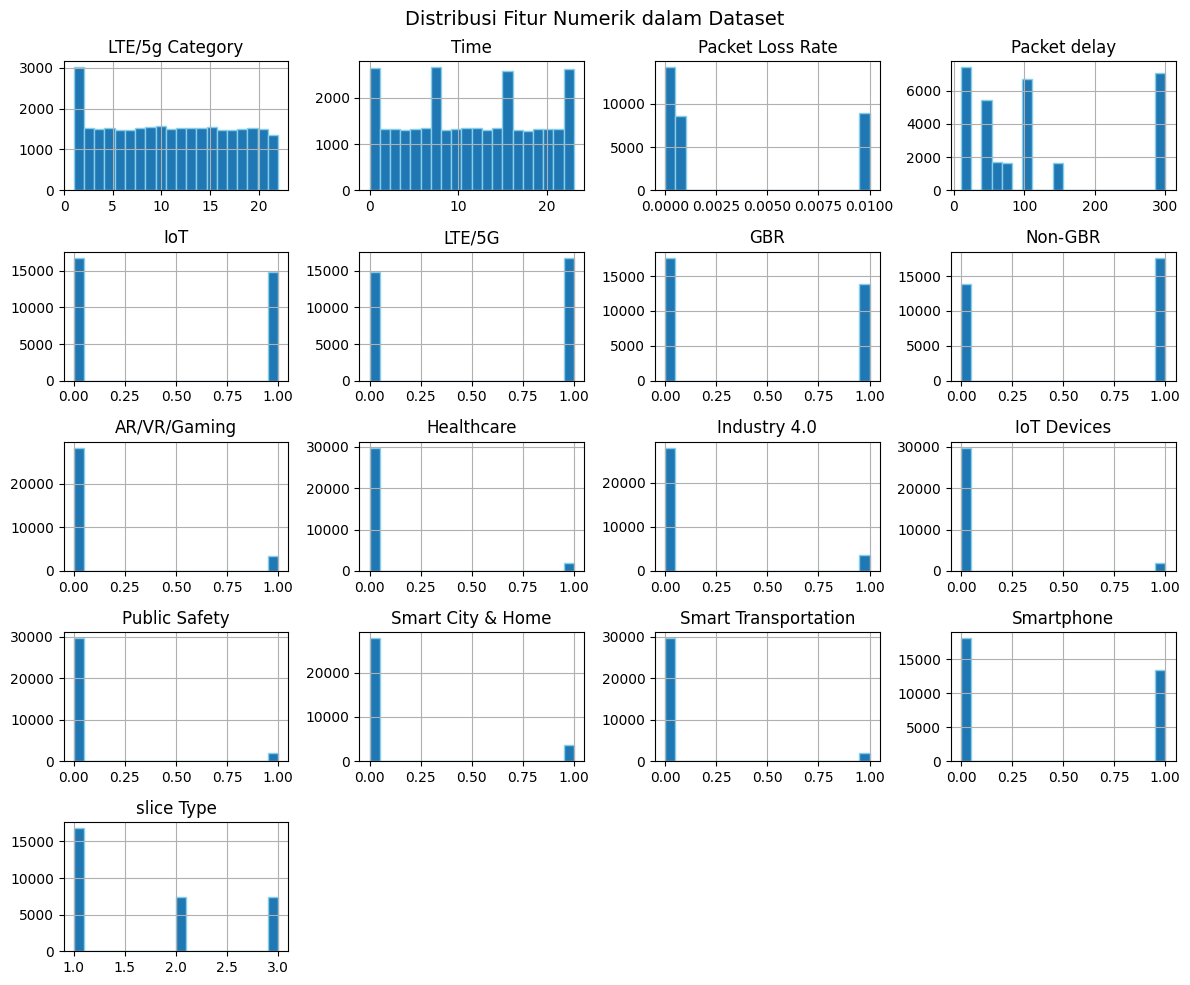

In [ ]:
plt.figure(figsize=(12, 6))
df.hist(bins=20, figsize=(12, 10), edgecolor="skyblue")
plt.suptitle("Distribusi Fitur Numerik dalam Dataset", fontsize=14)
plt.tight_layout()
plt.show()


**Correlation Heatmap**

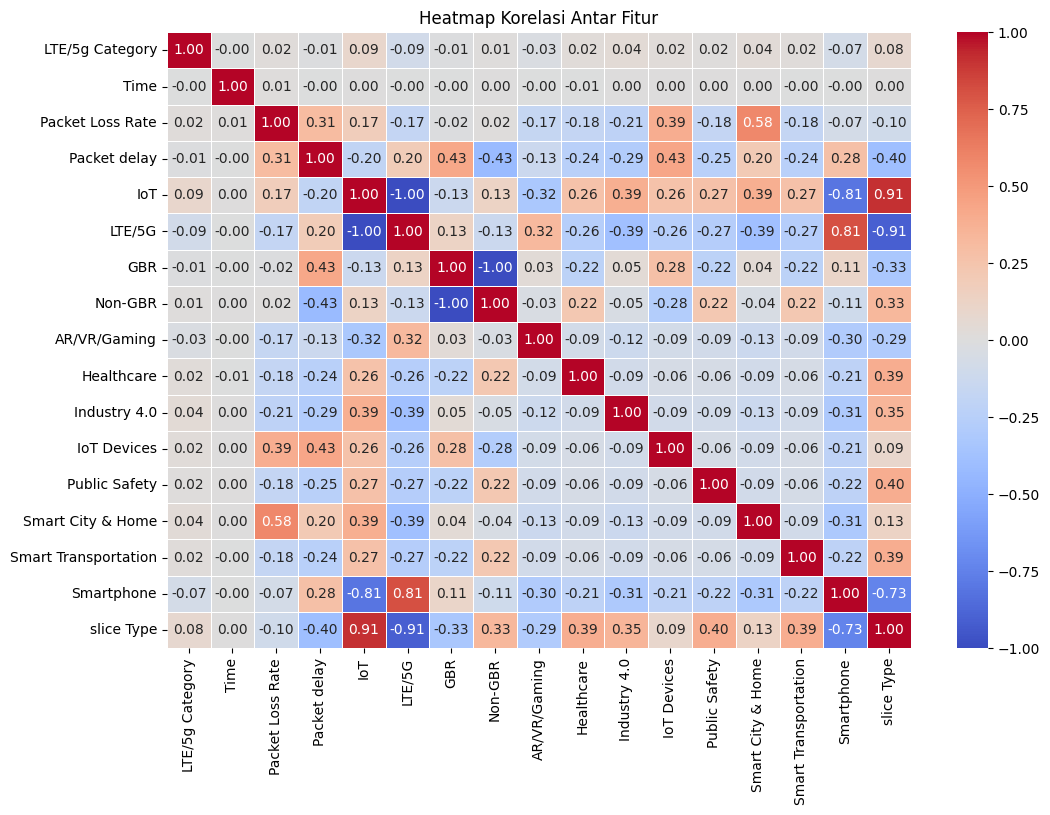

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


**Drop Missing Values**

In [ ]:
df = df.dropna()

**Label Encoding**

In [ ]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

**Split Train-Test**


In [ ]:
X = df.drop(columns=["slice Type"])
y = df["slice Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTotal Data Train  : {X_train.shape[0]}")
print(f"Total Data Test   : {X_test.shape[0]}")



Total Data Train  : 25266
Total Data Test   : 6317


**Decision Tree Classifier**

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

**Check Model Parameters**

In [ ]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

**Predition**

In [ ]:
prediction = model.predict(X_test)
prediction

array([3, 2, 3, ..., 1, 1, 1])

**Model Evaluation**


Accuracy               : 1.0000

Classification Report  :
              precision  recall  f1-score  support
1                   1.0     1.0       1.0   3316.0
2                   1.0     1.0       1.0   1482.0
3                   1.0     1.0       1.0   1519.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0   6317.0
weighted avg        1.0     1.0       1.0   6317.0


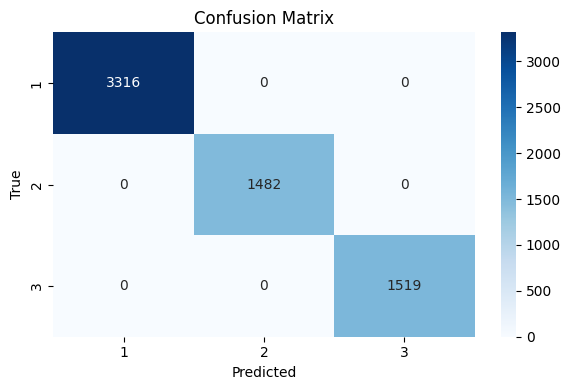

['decision_tree_model.joblib']

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy               : {accuracy:.4f}")

# Classification Report
class_report = classification_report(y_test, y_pred, output_dict=True)
class_report_df = pd.DataFrame(class_report).transpose()
print("\nClassification Report  :")
print(class_report_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(set(y_test)), yticklabels=sorted(set(y_test)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

joblib.dump(model, 'decision_tree_model.joblib')


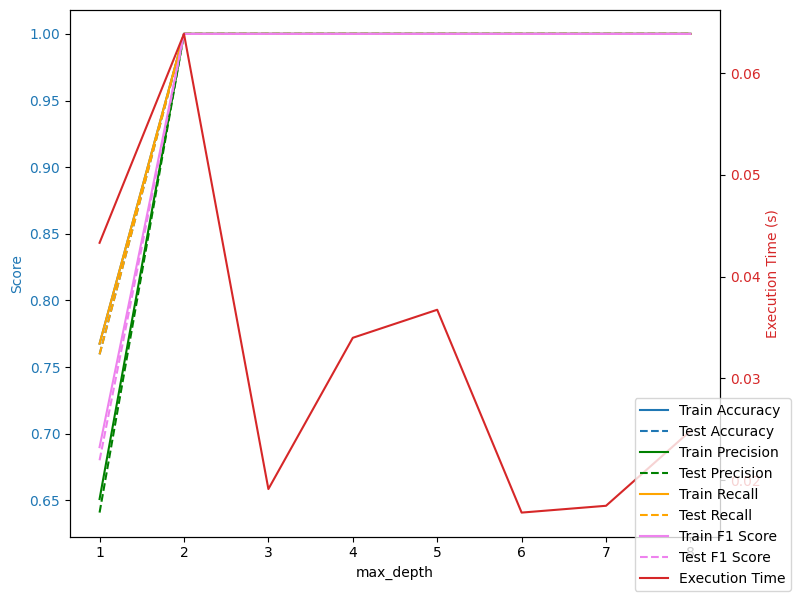

In [ ]:
import time

model = DecisionTreeClassifier()
params = range(1, 9)

train_accuracy_scores = []
test_accuracy_scores = []
train_precision_scores = []
test_precision_scores = []
train_recall_scores = []
test_recall_scores = []
train_f1_scores = []
test_f1_scores = []
exec_times = []

for max_depth in params:
    start_time = time.time()

    model.set_params(max_depth=max_depth)
    model.fit(X_train, y_train)

    end_time = time.time()

    exec_time = end_time - start_time

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')

    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')


    train_accuracy_scores.append(train_accuracy)
    test_accuracy_scores.append(test_accuracy)
    train_precision_scores.append(train_precision)
    test_precision_scores.append(test_precision)
    train_recall_scores.append(train_recall)
    test_recall_scores.append(test_recall)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)
    exec_times.append(exec_time)

fig, ax1 = plt.subplots(figsize=(8, 6))

color = 'tab:blue'
ax1.set_xlabel('max_depth')
ax1.set_ylabel('Score', color=color)
ax1.plot(params, train_accuracy_scores, color=color, label='Train Accuracy')
ax1.plot(params, test_accuracy_scores, color=color, linestyle='dashed', label='Test Accuracy')
ax1.plot(params, train_precision_scores, color='green', label='Train Precision')
ax1.plot(params, test_precision_scores, color='green', linestyle='dashed', label='Test Precision')
ax1.plot(params, train_recall_scores, color='orange', label='Train Recall')
ax1.plot(params, test_recall_scores, color='orange', linestyle='dashed', label='Test Recall')
ax1.plot(params, train_f1_scores, color='violet', label='Train F1 Score')
ax1.plot(params, test_f1_scores, color='violet', linestyle='dashed', label='Test F1 Score')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Execution Time (s)', color=color)
ax2.plot(params, exec_times, color=color, label='Execution Time')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.legend(loc="lower right")
plt.show()




**Feature Importance**


Feature Importance:
 LTE/5G                  0.615525
Packet delay            0.384475
Time                    0.000000
LTE/5g Category         0.000000
Packet Loss Rate        0.000000
IoT                     0.000000
GBR                     0.000000
Non-GBR                 0.000000
AR/VR/Gaming            0.000000
Healthcare              0.000000
Industry 4.0            0.000000
IoT Devices             0.000000
Public Safety           0.000000
Smart City & Home       0.000000
Smart Transportation    0.000000
Smartphone              0.000000
dtype: float64


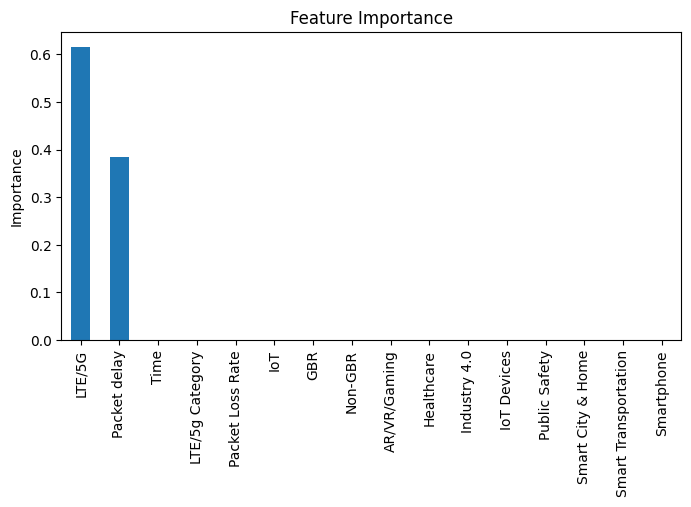

In [ ]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nFeature Importance:\n", feature_importance)

# Visualisasi feature importance
plt.figure(figsize=(8,4))
feature_importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.show()


**Decision Tree Visualization**

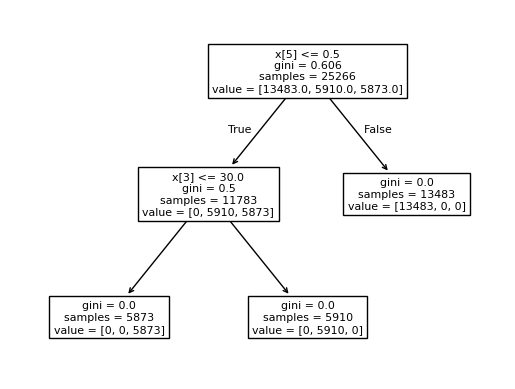

In [ ]:
from sklearn.tree import plot_tree
plot_tree(model)
plt.show()

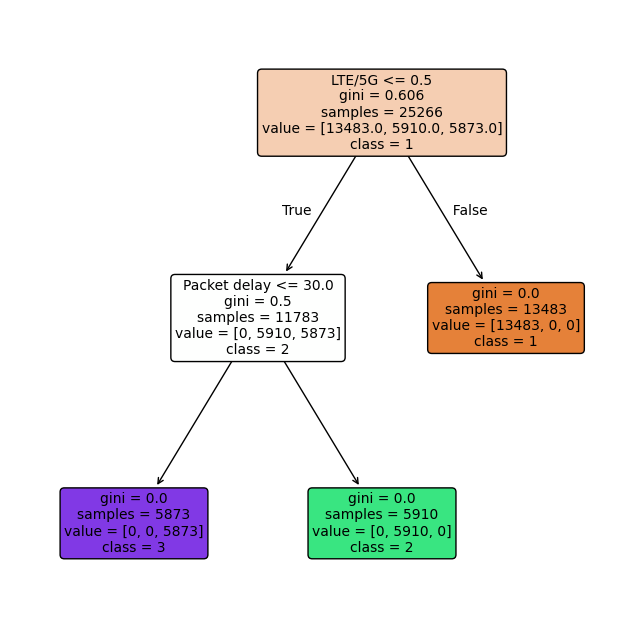

In [ ]:
plt.figure(figsize=(8,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in model.classes_],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()